# Laboration 3: Fashion MNIST

På föreläsningen tittade vi på MNIST, ett klassiskt dataset med handskrivna siffror. 

Ett lite svårare dataset men med samma dataformat som MNIST är [FashionMNIST](https://github.com/zalandoresearch/fashion-mnist). 

Här handlar det om att klassificera bilder på klädesplagg och skor. 

Bilderna är gråskala med 28x28 pixlar, precis som MNIST, men innehåller här alltså klädesplagg istället för siffror. Träningsdatan består av 60000 bilder (tillsammans med sina motsvarande klasser). Nedan är några exempel.

<center><img src="images/fashion-mnist-sprite.png" width=30%/></center>

Klasserna är
* T-shirt/top
* Trouser
* Pullover
* Dress
* Coat
* Sandal
* Shirt
* Sneaker
* Bag
* Ankle boot

## Uppgift
Skapa ett neuralt nät som kan klassificera bilder från FashionMNIST med en träffsäkerhet på minst **88.5%** när den evalueras (se nedan) på valideringsdata.

### Evaluering av modell
När du har tränat en modell som du vill testa börjar du med att spara modellen till en fil `fashion_model.onnx` med hjälp av `torch.onnx.export`, ett exempel på detta är
```python
model = torch.nn.Linear(1,1)

# ...

import torch.onnx
torch.onnx.export(model, # Din tränade modell
                  torch.ones((1, 1, 28, 28)), # En test tensor som krävs för exportering av modell. (input size = batch, kanaler, dim1, dim2). Ändra inte batch.
                  "fashion_model.onnx", # Filnamn för exporterad modell, behåll detta så att testscriptet hittar din fil
                  verbose=True, # Visa detaljer om exporten
                  input_names=["input"],  # Namnge första lagret till input (viktigt för testscript)
                  output_names=["output"]) # Namnge sista lagret till output (viktigt för testscript)
```

För att testa din modell så finns det ett testscript som laddar in `fashion_model.onnx` och testar den på valideringsdata.
Du kör testet i en terminal med
```bash
python shared/test_laboration3.py
```

## Tips

* Fashion MNIST har samma dataformat som MNIST.
* Ni kan lösa laborationen genom att skapa en modell av typen ANN eller ett CNN. 
* Fashion MNIST och MNIST har samma antal klasser, i båda fallen vill vi ha sannolikhetsdistributioner över 10 klasser.
* Även om det är samma dataformat så är det ett svårare problem, du behöver förmodligen testa olika metoder för att hitta en tillräckligt bra modell. Frågor du kan ställa dig:
  * Arkitekturen för modellen: Behövs fler antal lager? Större lager (dvs. med fler neuroner)?
  * Ändra inlärningstakten?
  * Träna längre? Ändra batch-size?
  * Testa andra aktiveringsfunktioner?
* Du kan implementera ditt program som notebook eller fristående program, det enda som behövs för godkännande via testskriptet är en tränad modell i `onnx` format.
* Längst ner i denna notebook finns ett exempel på hur du kan ladda in datan. Du ska bara träna på träningsdatan (dvs. `train=True`)

## Utmaning
Dessa frågor är inte obligatoriska för laborationen.

* Hur ser distributionen av klasser ut i träningsdatan? Är det lika många exempel av varje klädesplagg?
* Vilka bilder har din modell svårast att svara rätt på? Hur kan du ta reda på det?
* Vad händer om du ändrar på datan, t.ex lägger till små värden till alla pixlar, kan din modell fortfarande svara rätt?
* Gör en plot över träningen - minskar felet som du hade tänkt dig? Om du testar att prediktera på testsetet under träningen, kan du då hitta en punkt där mer träning inte hjälper dig att prediktera på testsetet?
* Testa att augmentera datan, t ex. kan man rotera, spegla eller flippa bilderna för att "skapa" fler träningsexempel. Kanske kan du då få ännu bättre accuracy.

# Exempel på dataladdning

In [3]:
from torchvision import datasets, transforms
import torch
import matplotlib.pyplot as plt
import numpy as np

In [4]:
#Ladda in datan - Behövs bara göras en gång. Därefter finns den i mappen data_fashion.
fashion_mnist = datasets.FashionMNIST('shared/datasets/', train=True, download=True, transform=transforms.ToTensor())

#Exempel på en train_loader som kan användas för att iterera över datan, med batch_size 128.
train_loader = torch.utils.data.DataLoader(fashion_mnist, batch_size=128)
examples = iter(train_loader)
bilder, plagg_id = next(examples)

Objektet `fashion_mnist` som skapas av `datasets.FashionMNIST` har en medlemsvariabel `classes` som kan vara användbar

In [5]:
fashion_mnist.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

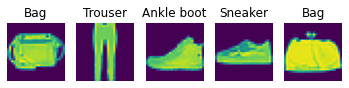

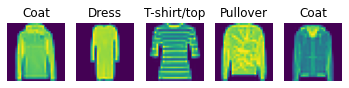

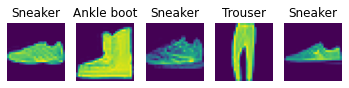

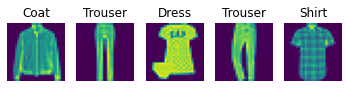

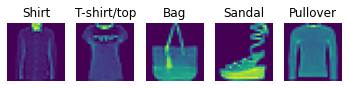

In [6]:
# Visa 5 exempel tillsammans med sin klass m.h.a klasslistan ovan

for _ in range(5):
    idx = np.random.randint(0, len(bilder)-5)
    plt.figure(figsize=(6, 2))
    for n, (bild, plagg) in enumerate(zip(bilder[idx:idx+5], plagg_id[idx:idx+5])):
        plt.subplot(1, 5, n + 1)
        plt.imshow(bild[0])
        plt.axis("off")
        plt.title(fashion_mnist.classes[plagg.item()])